c:\Users\24280666\AppData\Local\miniconda3\envs\causal_env\lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
INFO:datazets.datazets:Downloading [asia.zip] dataset from github source..


[bnlearn] >Import <asia>


INFO:datazets.datazets:Extracting files..


[bnlearn] >Loading bif file <c:\Users\24280666\AppData\Local\miniconda3\envs\causal_env\lib\site-packages\datazets\data\asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK
      asia  tub  smoke  lung  bronc  either  xray  dysp
0        1    1      1     1      1       1     0     1
1        1    1      0     1      0       1     1     0
2        1    0      0     1      0       0     0     0
3        1    1      1     1      1       1     1     1
4        1    1      0     1      0       1     1     0
...    ...  ...    ...   ...    ...     ...   ...   ...
2995     1    1      1     1      1       1     1     1
2996     1    1      1     1      1       1     1     0
299

  0%|          | 0/8 [00:00<?, ?it/s]

[[ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 -1  0  0]
 [ 0  0  0 -1 -1  0  0  0]
 [ 0  0 -1  0  0 -1  0  0]
 [ 0  0 -1  0  0  0  0 -1]
 [ 0  1  0  1  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0]]


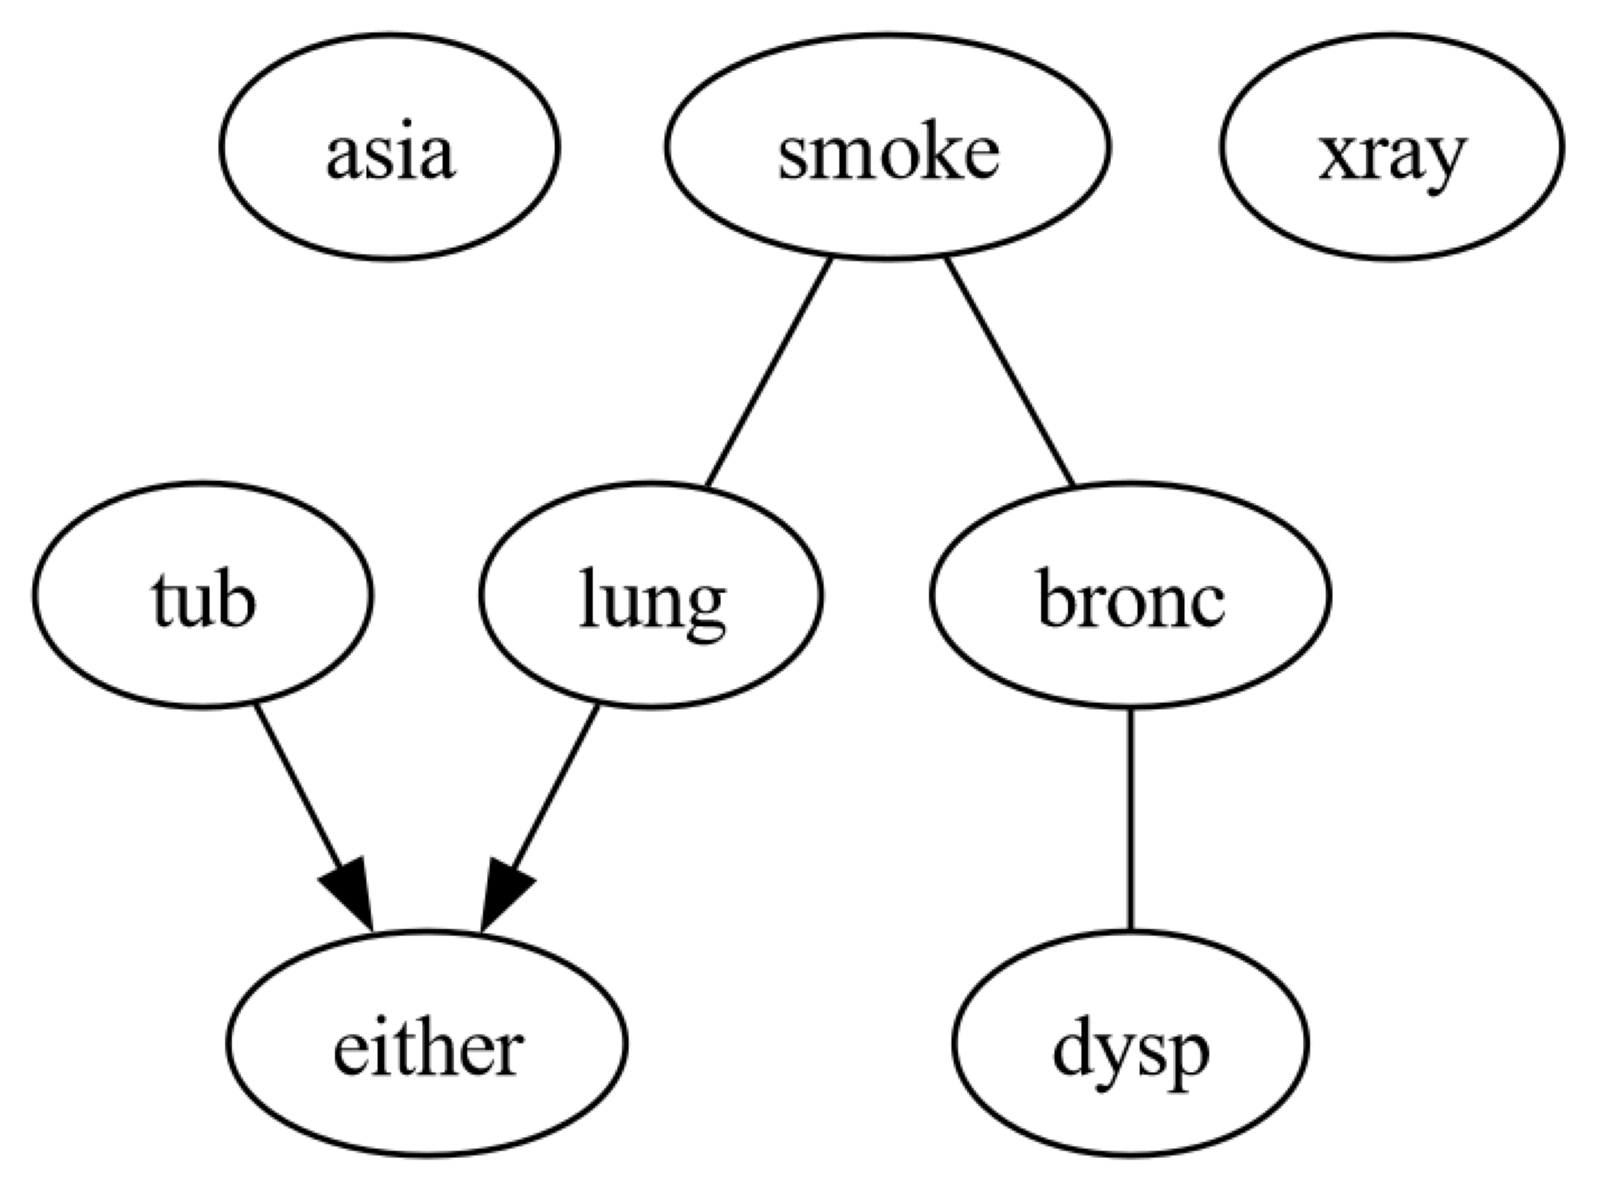

In [1]:
import bnlearn as bn
from causallearn.search.ConstraintBased.PC import pc;

asia_model = bn.import_DAG('asia')
df_asia = bn.sampling(asia_model, n = 3000, methodtype='bayes')
print(df_asia)

data = df_asia.to_numpy()
print(data)

cg = pc(data, indep_test='chisq')
print(cg.G.graph)

labels = list(df_asia.columns)
cg.draw_pydot_graph(labels=labels)